# 08 — Training-seed uncertainty
Refit the three frequentist specifications across independent initialization seeds. The data split, projected calibration directions, data order, and forecast random numbers are held fixed. This isolates initialization/optimization variability and combines it with serial sampling uncertainty through a hierarchical seed–moving-block bootstrap.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.evaluation import paired_seed_block_bootstrap
from innovcal.experiments import run_frequentist_seed_comparison
OUT = ROOT / 'results' / 'seed_uncertainty'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
returns = pd.read_csv(ROOT / 'data' / 'processed' / 'financial_returns.csv', index_col=0, parse_dates=True)
returns = returns[['AAPL', 'JPM', 'XOM', 'WMT']].dropna().sort_index()
assert returns.index.is_monotonic_increasing and not returns.index.has_duplicates
TRAINING_SEEDS = [611, 619, 631, 641, 647, 653, 661, 673, 683, 691]
print(f'{len(returns)} observations; {len(TRAINING_SEEDS)} seeds × 3 models = {3 * len(TRAINING_SEEDS)} fits')

4779 observations; 10 seeds × 3 models = 30 fits


## Fit the matched repetitions
This is the expensive cell. Ten seeds are the primary specification. For a pipeline check only, temporarily use the first two seeds, but restore all ten before interpreting results.

In [3]:
training = TrainingConfig(epochs=200, batch_size=64, patience=25, seed=606, selection_metric='nll')
result = run_frequentist_seed_comparison(
    returns.to_numpy(), TRAINING_SEEDS,
    model_config=CARNNConfig(input_dim=4, hidden_dim=32),
    training_config=training, lambda_cal=100.0, lambda_seq=2000.0,
    projection_seed=606, forecast_seed=20_606, n_forecast_samples=500,
)
display(result.metrics.groupby('model').agg(['mean', 'std']))

training_seed            best_epoch                 rmse  \
                           mean        std       mean        std      mean   
model                                                                        
CA-RNN                    651.0  26.566478       42.4   7.089899  0.950396   
CA-RNN sequential         651.0  26.566478       42.2   6.908931  0.947946   
RNN                       651.0  26.566478       30.2  11.183321  0.939856   

                            energy_score            coverage            ...  \
                        std         mean       std      mean       std  ...   
model                                                                   ...   
CA-RNN             0.001743     1.156251  0.002008  0.866641  0.005216  ...   
CA-RNN sequential  0.001918     1.153081  0.002417  0.876959  0.005845  ...   
RNN                0.001191     1.145041  0.001445  0.871682  0.005707  ...   

                  pit_mean_absolute_autocorrelation           pit_mean_ks  \
                                               mean       std        mean   
model                                                                       
CA-RNN                                     0.038585  0.001579    0.056731   
CA-RNN sequential                          0.037910  0.001004    0.056231   
RNN                                        0.031359  0.000849    0.059706   

                            coordinate_pit_calibration_error            \
                        std                             mean       std   
model                                                                    
CA-RNN             0.002184                         0.001479  0.000149   
CA-RNN sequential  0.002385                         0.001517  0.000143   
RNN                0.001710                         0.001766  0.000131   

                  coordinate_pit_mean_absolute_autocorrelation            \
                                                          mean       std   
model                                                                      
CA-RNN                                                0.035929  0.001728   
CA-RNN sequential                                     0.036815  0.000785   
RNN                                                   0.030271  0.001569   

                  coordinate_pit_mean_ks            
                                    mean       std  
model                                               
CA-RNN                          0.062869  0.003801  
CA-RNN sequential               0.065735  0.003719  
RNN                             0.069018  0.003047  

[3 rows x 26 columns]

In [4]:
result.metrics.to_csv(OUT / 'seed_metrics.csv', index=False)
payload = {'target': result.target, 'projections': result.projections, 'training_seeds': np.asarray(TRAINING_SEEDS)}
manifest = []
for index, (name, samples) in enumerate(result.forecast_samples.items()):
    key = f'samples_{index}'
    payload[key] = samples
    manifest.append({'model': name, 'array_key': key})
np.savez_compressed(OUT / 'seed_forecasts.npz', **payload)
pd.DataFrame(manifest).to_csv(OUT / 'seed_forecast_manifest.csv', index=False)
print('Saved metrics and retained forecasts; later cells can be rerun without refitting.')

Saved metrics and retained forecasts; later cells can be rerun without refitting.


In [5]:
COMPARISONS = [('CA-RNN', 'RNN'), ('CA-RNN sequential', 'CA-RNN'), ('CA-RNN sequential', 'RNN')]
inference = paired_seed_block_bootstrap(
    result.target, result.forecast_samples, COMPARISONS, result.projections,
    block_length=20, n_bootstrap=2000, confidence=0.95, seed=808,
)
display(inference)
inference.to_csv(OUT / 'hierarchical_seed_block_bootstrap.csv', index=False)

,n_seeds,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
0,10,957,20,2000,CA-RNN,RNN,mean_squared_error,0.019926,0.001644,0.016784,0.023091,0.0000
1,10,957,20,2000,CA-RNN,RNN,energy_score,0.011210,0.000833,0.009610,0.012809,0.0000
2,10,957,20,2000,CA-RNN,RNN,interval_score,0.033622,0.008175,0.019077,0.051845,0.0000
3,10,957,20,2000,CA-RNN,RNN,interval_width,0.004634,0.012711,-0.022359,0.027272,0.4930
4,10,957,20,2000,CA-RNN,RNN,coverage,-0.005042,0.001627,-0.008830,-0.002429,1.0000
5,10,957,20,2000,CA-RNN,RNN,coverage_error,0.005042,0.001627,0.002429,0.008830,0.0000
6,10,957,20,2000,CA-RNN,RNN,pit_calibration_error,-0.000133,0.000047,-0.000269,-0.000083,1.0000
7,10,957,20,2000,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.007227,0.001311,0.000185,0.005183,0.0160
8,10,957,20,2000,CA-RNN sequential,CA-RNN,mean_squared_error,-0.004650,0.000728,-0.006196,-0.003357,1.0000
9,10,957,20,2000,CA-RNN sequential,CA-RNN,energy_score,-0.003171,0.000470,-0.004150,-0.002311,1.0000


In [6]:
loss_metrics = {'mean_squared_error', 'energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error', 'pit_mean_absolute_autocorrelation'}
decisions = inference.assign(interval_excludes_zero=(inference.ci_lower > 0) | (inference.ci_upper < 0))
decisions['direction'] = 'descriptive'
is_loss = decisions.metric.isin(loss_metrics)
decisions.loc[is_loss & (decisions.ci_upper < 0), 'direction'] = 'candidate favored'
decisions.loc[is_loss & (decisions.ci_lower > 0), 'direction'] = 'comparator favored'
decisions.loc[is_loss & ~decisions.interval_excludes_zero, 'direction'] = 'unresolved'
display(decisions[['candidate', 'comparator', 'metric', 'difference', 'ci_lower', 'ci_upper', 'direction']])
decisions.to_csv(OUT / 'hierarchical_decisions.csv', index=False)

,candidate,comparator,metric,difference,ci_lower,ci_upper,direction
0,CA-RNN,RNN,mean_squared_error,0.019926,0.016784,0.023091,comparator favored
1,CA-RNN,RNN,energy_score,0.011210,0.009610,0.012809,comparator favored
2,CA-RNN,RNN,interval_score,0.033622,0.019077,0.051845,comparator favored
3,CA-RNN,RNN,interval_width,0.004634,-0.022359,0.027272,descriptive
4,CA-RNN,RNN,coverage,-0.005042,-0.008830,-0.002429,descriptive
5,CA-RNN,RNN,coverage_error,0.005042,0.002429,0.008830,comparator favored
6,CA-RNN,RNN,pit_calibration_error,-0.000133,-0.000269,-0.000083,candidate favored
7,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.007227,0.000185,0.005183,comparator favored
8,CA-RNN sequential,CA-RNN,mean_squared_error,-0.004650,-0.006196,-0.003357,candidate favored
9,CA-RNN sequential,CA-RNN,energy_score,-0.003171,-0.004150,-0.002311,candidate favored


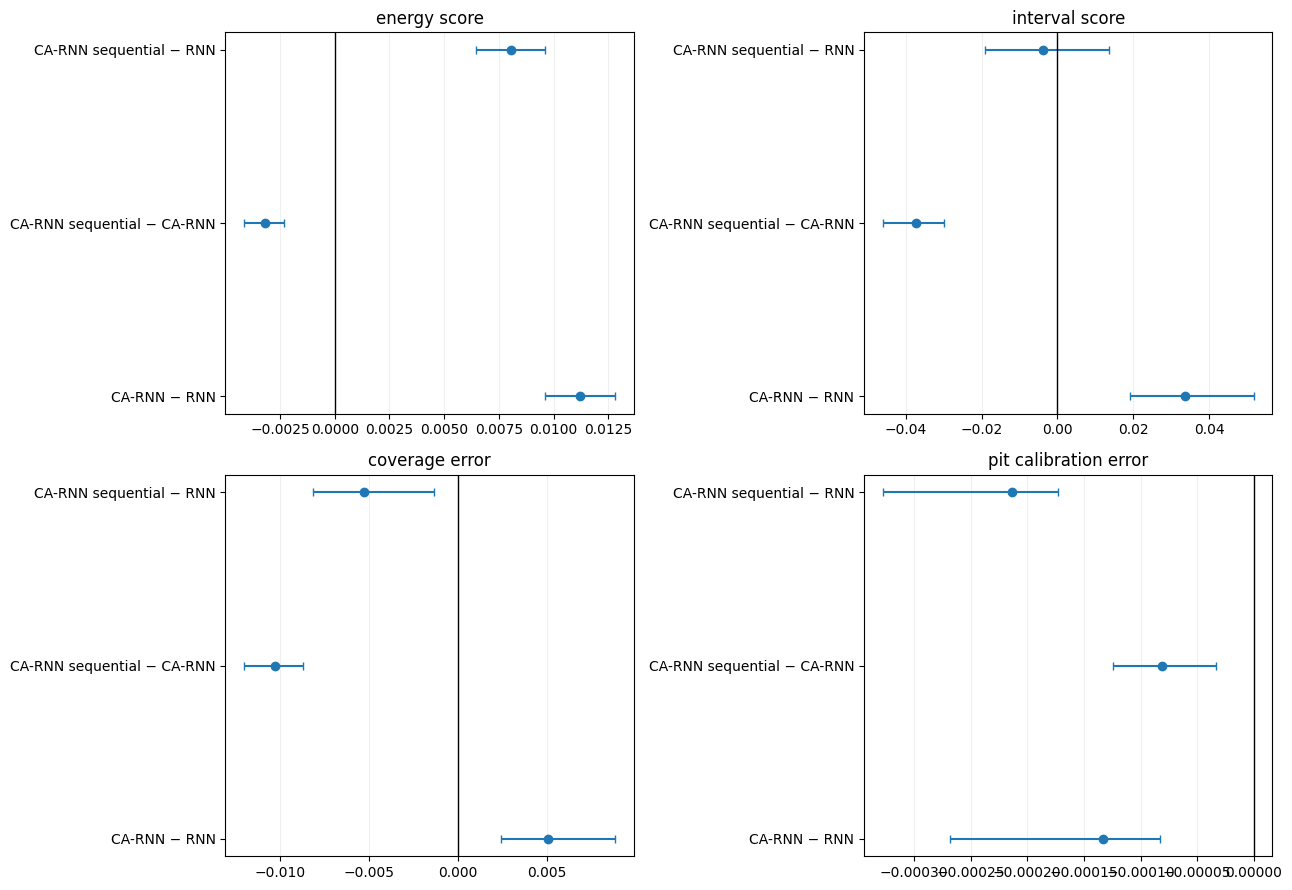

In [7]:
shown = ['energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error']
figure_data = inference[inference.metric.isin(shown)].copy()
figure_data['comparison'] = figure_data.candidate + ' − ' + figure_data.comparator
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, metric in zip(axes.flat, shown):
    subset = figure_data[figure_data.metric.eq(metric)].reset_index(drop=True)
    axis.errorbar(subset.difference, range(len(subset)), xerr=[subset.difference-subset.ci_lower, subset.ci_upper-subset.difference], fmt='o', capsize=3)
    axis.axvline(0, color='black', linewidth=1)
    axis.set_yticks(range(len(subset)), subset.comparison)
    axis.set_title(metric.replace('_', ' ')); axis.grid(axis='x', alpha=.2)
plt.tight_layout()
fig.savefig(OUT / 'hierarchical_intervals.png', dpi=180, bbox_inches='tight')

## Interpretation
The estimand is the average candidate-minus-comparator effect over the ten chosen optimization seeds and the observed financial test period. Negative differences favor the candidate for loss metrics. Raw coverage and interval width are descriptive; coverage error is distance from 90%. A hierarchical interval containing zero is unresolved, not evidence of equality. This experiment addresses initialization and serial sampling variability, but it still conditions on one market split, architecture, and hyperparameter-development path.